# Credit Card Default Prediction

- **Name:** Jay Vaghasiya
- **Branch:** CSE 2y
- **Enrollment No.:** 23114101


### Detailed Explaination of every step preformed is documented in Project Report

# Importing Libraries and loading data

In [2083]:
import pandas as pd
import numpy as np

In [2084]:
train_df = pd.read_csv('train_dataset_final1.csv')

In [2085]:
print(train_df.shape)
train_df.head()

(25247, 27)


,Customer_ID,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,...,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
0,5017,2,0,2,60000,25.0,2,2,2,0,...,20750.63,2000.21,0.00,1134.85,1821.78,1500.03,1500.24,41511.50,0.03,0
1,5018,2,1,1,290000,24.0,0,0,-2,-2,...,1350.30,0.00,0.17,0.00,2700.10,0.00,1349.72,2534.50,0.27,0
2,5019,1,0,2,180000,63.0,0,0,0,0,...,52991.51,2086.94,2199.99,1845.66,2000.35,1923.00,1999.78,50422.00,0.04,0
3,5020,1,1,2,210000,43.0,0,0,0,0,...,76945.47,3348.07,3380.91,3400.45,2683.97,2744.00,2892.10,86229.50,0.04,0
4,5021,2,0,1,280000,32.0,-2,-2,-2,-2,...,1.35,999.78,3186.27,45027.78,2100.09,0.01,0.27,11814.33,0.72,0


# Data Cleaning

### Checking which columns contains null values 

In [2086]:
train_df.isnull().sum()

Customer_ID             0
marriage                0
sex                     0
education               0
LIMIT_BAL               0
age                   126
pay_0                   0
pay_2                   0
pay_3                   0
pay_4                   0
pay_5                   0
pay_6                   0
Bill_amt1               0
Bill_amt2               0
Bill_amt3               0
Bill_amt4               0
Bill_amt5               0
Bill_amt6               0
pay_amt1                0
pay_amt2                0
pay_amt3                0
pay_amt4                0
pay_amt5                0
pay_amt6                0
AVG_Bill_amt            0
PAY_TO_BILL_ratio       0
next_month_default      0
dtype: int64

In [2087]:
# fill missing values with median of the column

train_df.fillna(train_df.median(), inplace=True)
train_df.isnull().sum()

Customer_ID           0
marriage              0
sex                   0
education             0
LIMIT_BAL             0
age                   0
pay_0                 0
pay_2                 0
pay_3                 0
pay_4                 0
pay_5                 0
pay_6                 0
Bill_amt1             0
Bill_amt2             0
Bill_amt3             0
Bill_amt4             0
Bill_amt5             0
Bill_amt6             0
pay_amt1              0
pay_amt2              0
pay_amt3              0
pay_amt4              0
pay_amt5              0
pay_amt6              0
AVG_Bill_amt          0
PAY_TO_BILL_ratio     0
next_month_default    0
dtype: int64

### Checking for duplicates

In [2088]:
train_df.duplicated().sum()

np.int64(0)

### Handling Inconsistent data

1) marriage

In [2089]:
train_df['marriage'].value_counts()

marriage
2    13441
1    11480
3      273
0       53
Name: count, dtype: int64

In [2090]:
# since we already have 3 for others, convert all 0's to 3's

train_df['marriage'] = train_df['marriage'].replace(0, 3)

train_df['marriage'].value_counts()

marriage
2    13441
1    11480
3      326
Name: count, dtype: int64

2. education

In [2091]:
train_df['education'].value_counts()

education
2    11717
1     8988
3     4115
5      253
4      116
6       44
0       14
Name: count, dtype: int64

In [2092]:
# since 5,6,0 total 253 + 44 + 14 = 311, which is more than 1% of the data, we will convert them to single category 4

train_df['education'] = train_df['education'].replace([5, 6, 0], 4)

train_df['education'].value_counts()

education
2    11717
1     8988
3     4115
4      427
Name: count, dtype: int64

3. AVG_Bill_amt

In [2093]:
train_df['AVG_Bill_amt'].describe()

count     25247.000000
mean      44859.647485
std       62819.226119
min      -56043.170000
25%        4858.670000
50%       21102.830000
75%       57136.580000
max      877313.830000
Name: AVG_Bill_amt, dtype: float64

In [2094]:
# Replace negative AVG_Bill_amt with mean of Bill_amt1 to Bill_amt6

bill_cols = ['Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6']
mask = train_df['AVG_Bill_amt'] < 0
train_df.loc[mask, 'AVG_Bill_amt'] = train_df.loc[mask, bill_cols].mean(axis=1)


4. PAY_TO_Bill_ratio

In [2095]:
train_df['PAY_TO_BILL_ratio'].describe()

count    25247.000000
mean         0.362962
std          5.047206
min       -546.930000
25%          0.040000
50%          0.090000
75%          0.590000
max        205.380000
Name: PAY_TO_BILL_ratio, dtype: float64

In [2096]:
negs = train_df['PAY_TO_BILL_ratio'] < 0

print(f"Number of negative PAY_TO_BILL_ratio: {negs.sum()}")

Number of negative PAY_TO_BILL_ratio: 105


In [2097]:
# cliff negative values to 0

train_df.loc[negs, 'PAY_TO_BILL_ratio'] = 0

# EDA

In [2098]:
import matplotlib.pyplot as plt
import seaborn as sns

### Observing both classes

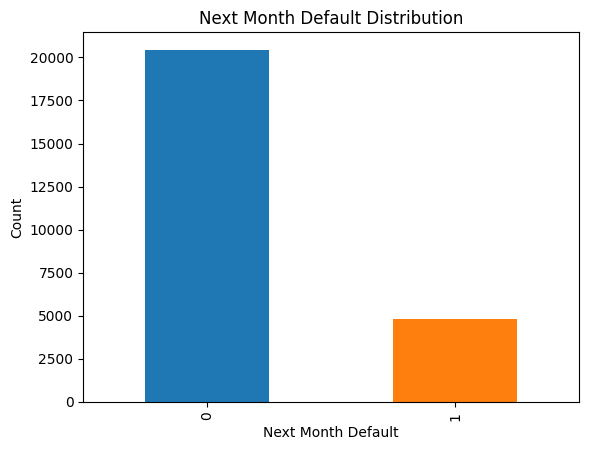

In [2099]:
train_df['next_month_default'].value_counts().plot(kind='bar', color=["#1f77b4", "#ff7f0e"])
plt.title('Next Month Default Distribution')
plt.xlabel('Next Month Default')
plt.ylabel('Count')
plt.show()

### education, marriage, sex 

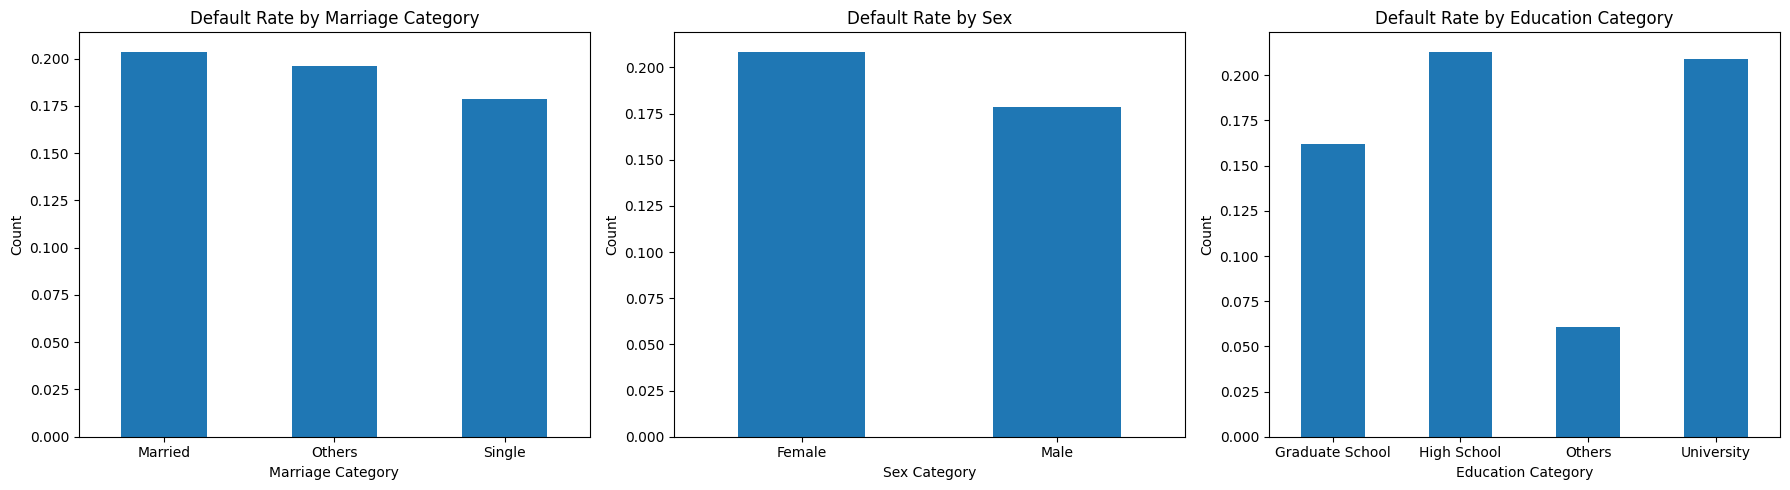

In [2100]:
# EDA for marriage, sex and education categories

# Define mapping dictionaries
marriage_map = {1: "Married", 2: "Single", 3: "Others"}
sex_map = {0: "Female", 1: "Male"}
education_map = {1: "Graduate School", 2: "University", 3: "High School", 4: "Others"}

# Group and count without adding columns
marriage_counts = train_df.groupby(train_df["marriage"].map(marriage_map))["next_month_default"].mean()
sex_counts = train_df.groupby(train_df["sex"].map(sex_map))["next_month_default"].mean()
education_counts = train_df.groupby(train_df["education"].map(education_map))["next_month_default"].mean()

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Marriage
marriage_counts.plot(kind='bar', ax=axes[0])
axes[0].set_title('Default Rate by Marriage Category')
axes[0].set_xlabel('Marriage Category')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(marriage_counts.index, rotation=0)

# Sex
sex_counts.plot(kind='bar', ax=axes[1])
axes[1].set_title('Default Rate by Sex')
axes[1].set_xlabel('Sex Category')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(sex_counts.index, rotation=0)

# Education
education_counts.plot(kind='bar', ax=axes[2])
axes[2].set_title('Default Rate by Education Category')
axes[2].set_xlabel('Education Category')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(education_counts.index, rotation=0)

plt.tight_layout()
plt.show()


### age

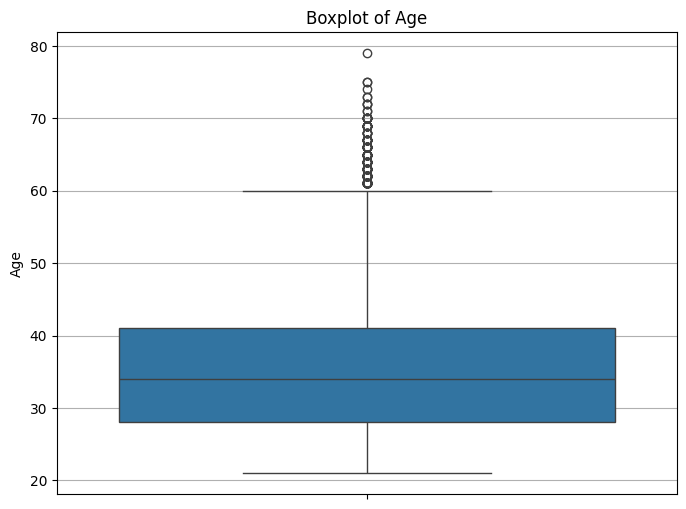

Number of outliers in age: 217


In [2101]:
# Boxplot for age

plt.figure(figsize=(8, 6))

sns.boxplot(y='age', data=train_df)
plt.title('Boxplot of Age')
plt.ylabel('Age')
plt.grid(axis='y')
plt.show()

# Number of outliers in age

Q1 = train_df['age'].quantile(0.25)
Q3 = train_df['age'].quantile(0.75)
IQR = Q3 - Q1
outliers = train_df[(train_df['age'] < (Q1 - 1.5 * IQR)) | (train_df['age'] > (Q3 + 1.5 * IQR))]
print(f'Number of outliers in age: {len(outliers)}')

In [2102]:
# Capping the outliers to upper IQR bound

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

train_df['age'] = train_df['age'].clip(lower=lower_bound, upper=upper_bound)

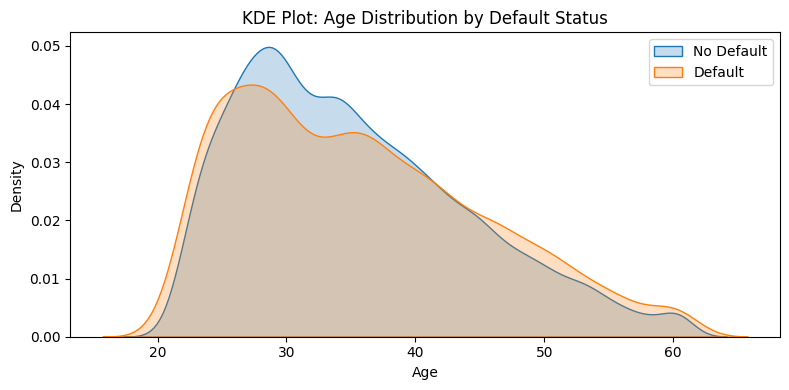

In [2103]:

# KDE plot: Age distributions split by default status
plt.figure(figsize=(8, 4))
sns.kdeplot(
    data=train_df[train_df['next_month_default'] == 0],
    x='age',
    label='No Default',
    fill=True,
    color="#1f77b4"
)
sns.kdeplot(
    data=train_df[train_df['next_month_default'] == 1],
    x='age',
    label='Default',
    fill=True,
    color="#ff7f0e"
)
plt.title("KDE Plot: Age Distribution by Default Status")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

### Limit Balance

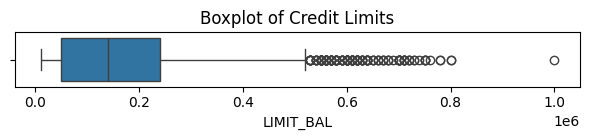

In [2104]:
# EDA for Limit Balance
# 2. Boxplot of Credit Limit
plt.figure(figsize=(6, 1.5))
sns.boxplot(x=train_df['LIMIT_BAL'])
plt.title("Boxplot of Credit Limits")
plt.tight_layout()
plt.show()

In [2105]:
# number of outliers in LIMIT_BAL

Q1 = train_df['LIMIT_BAL'].quantile(0.25)
Q3 = train_df['LIMIT_BAL'].quantile(0.75)
IQR = Q3 - Q1

outliers = train_df[(train_df['LIMIT_BAL'] < (Q1 - 1.5 * IQR)) | (train_df['LIMIT_BAL'] > (Q3 + 1.5 * IQR))]
print(f'Number of outliers in LIMIT_BAL: {len(outliers)}')

Number of outliers in LIMIT_BAL: 148


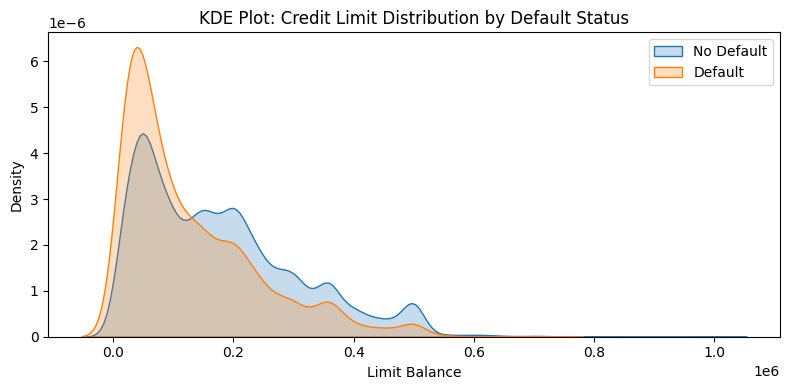

In [2106]:
# kde plot for Limit Balance with default status

plt.figure(figsize=(8, 4))
sns.kdeplot(
    data=train_df[train_df['next_month_default'] == 0],
    x='LIMIT_BAL',
    label='No Default',
    fill=True,
    color="#1f77b4"
)
sns.kdeplot(
    data=train_df[train_df['next_month_default'] == 1],
    x='LIMIT_BAL',
    label='Default',
    fill=True,
    color="#ff7f0e"
)
plt.title("KDE Plot: Credit Limit Distribution by Default Status")
plt.xlabel("Limit Balance")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

### Bill amounts

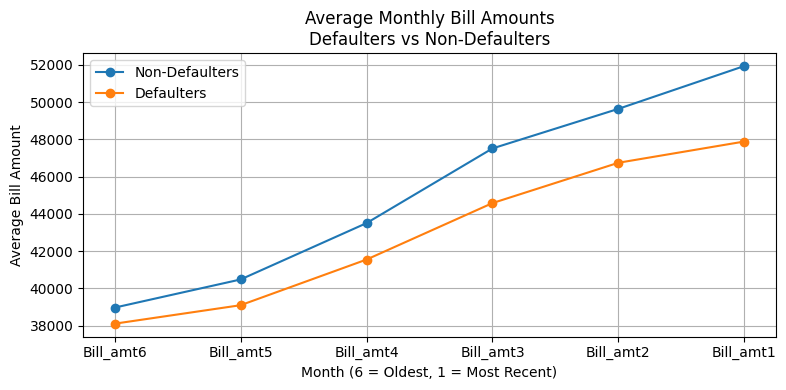

In [2107]:
# EDA for Bill Amounts# Columns for monthly bill amounts
bill_cols = ['Bill_amt6', 'Bill_amt5', 'Bill_amt4', 'Bill_amt3', 'Bill_amt2', 'Bill_amt1']  # reversed for chronological order

# Group by default status
bill_means = train_df.groupby('next_month_default')[bill_cols].mean().T
bill_means.columns = ['Non-Defaulters', 'Defaulters'] if 0 in bill_means.columns else ['Defaulters', 'Non-Defaulters']

# Plot
bill_means.plot(figsize=(8, 4), marker='o')
plt.title("Average Monthly Bill Amounts\nDefaulters vs Non-Defaulters")
plt.xlabel("Month (6 = Oldest, 1 = Most Recent)")
plt.ylabel("Average Bill Amount")
plt.grid(True)
plt.tight_layout()
plt.show()

### Average Bill amount 

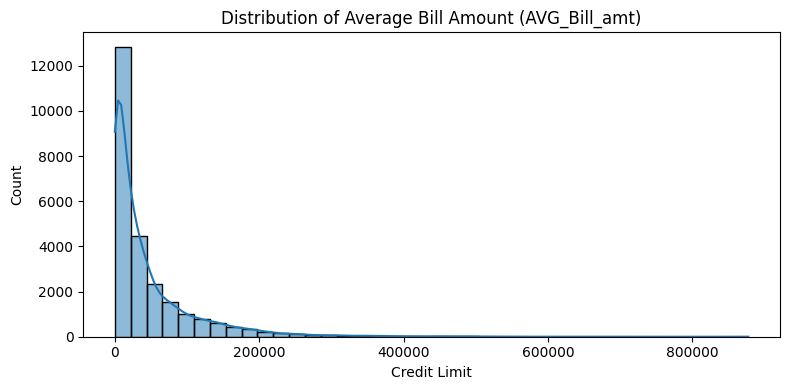

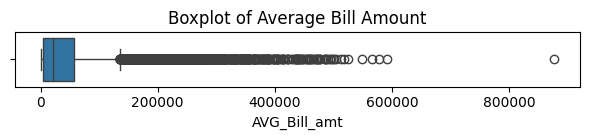

In [2108]:
plt.figure(figsize=(8, 4))
sns.histplot(train_df['AVG_Bill_amt'], bins=40, kde=True)
plt.title("Distribution of Average Bill Amount (AVG_Bill_amt)")
plt.xlabel("Credit Limit")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 2. Boxplot of Credit Limit
plt.figure(figsize=(6, 1.5))
sns.boxplot(x=train_df['AVG_Bill_amt'])
plt.title("Boxplot of Average Bill Amount")
plt.tight_layout()
plt.show()

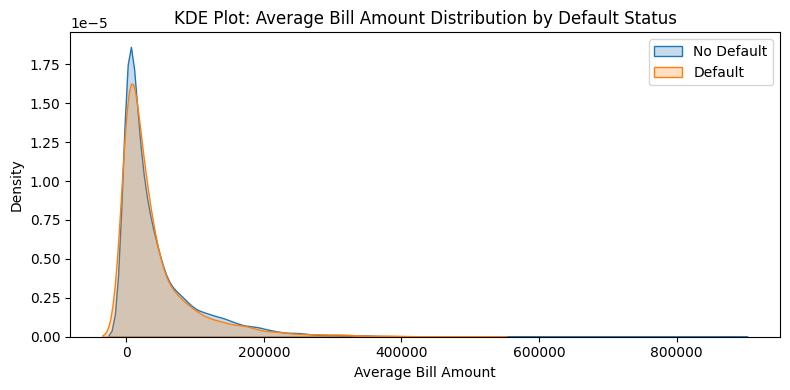

In [2109]:
# kde plot for AVG_Bill_amt with default status

plt.figure(figsize=(8, 4))
sns.kdeplot(
    data=train_df[train_df['next_month_default'] == 0],
    x='AVG_Bill_amt',
    label='No Default',
    fill=True,
    color="#1f77b4"
)
sns.kdeplot(
    data=train_df[train_df['next_month_default'] == 1],
    x='AVG_Bill_amt',
    label='Default',
    fill=True,
    color="#ff7f0e"
)

plt.title("KDE Plot: Average Bill Amount Distribution by Default Status")
plt.xlabel("Average Bill Amount")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

In [2110]:
Q1 = train_df['AVG_Bill_amt'].quantile(0.25)
Q3 = train_df['AVG_Bill_amt'].quantile(0.75)

IQR = Q3 - Q1

outliers = train_df[(train_df['AVG_Bill_amt'] < (Q1 - 1.5 * IQR)) | (train_df['AVG_Bill_amt'] > (Q3 + 1.5 * IQR))]
print(f'Number of outliers in AVG_Bill_amt: {len(outliers)}')

Number of outliers in AVG_Bill_amt: 2158


### Payment status

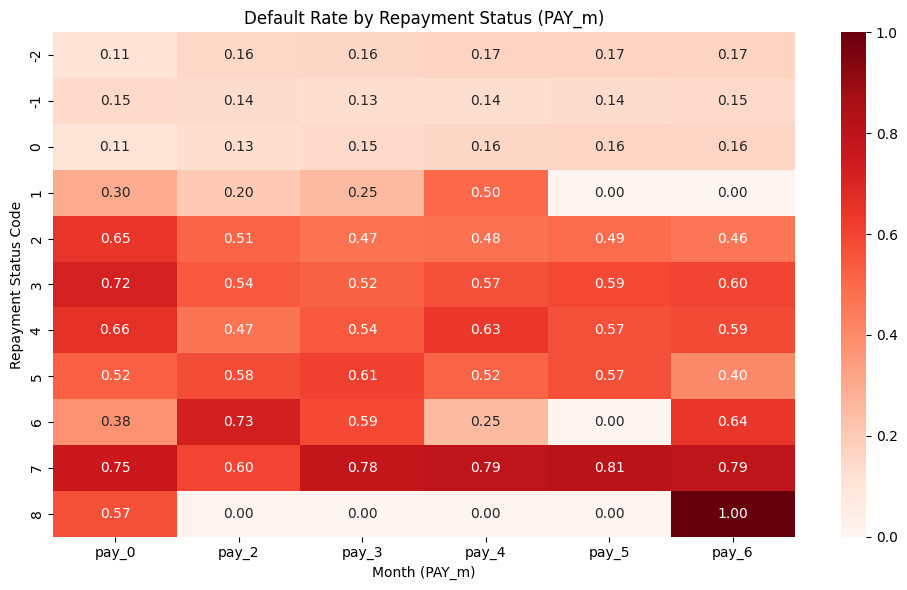

In [2111]:
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']

default_rate_map = pd.DataFrame()

for col in pay_cols:
    default_rate = train_df.groupby(col)['next_month_default'].mean()
    default_rate_map[col] = default_rate

# Clean and sort index for proper display
default_rate_map = default_rate_map.fillna(0).sort_index()

# Plot heatmap of default rates
plt.figure(figsize=(10, 6))
sns.heatmap(default_rate_map, annot=True, fmt=".2f", cmap="Reds")
plt.title("Default Rate by Repayment Status (PAY_m)")
plt.xlabel("Month (PAY_m)")
plt.ylabel("Repayment Status Code")
plt.tight_layout()
plt.show()


### New features from payment status pattern

In [2112]:
# Feature 1: Number of months delayed
train_df['num_months_late'] = train_df[pay_cols].apply(lambda row: sum(row >= 1), axis=1)

# Feature 2: Longest delay streak
def longest_streak(row):
    streak = max_streak = 0
    for val in row:
        if val >= 1:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

train_df['longest_delay_streak'] = train_df[pay_cols].apply(longest_streak, axis=1)


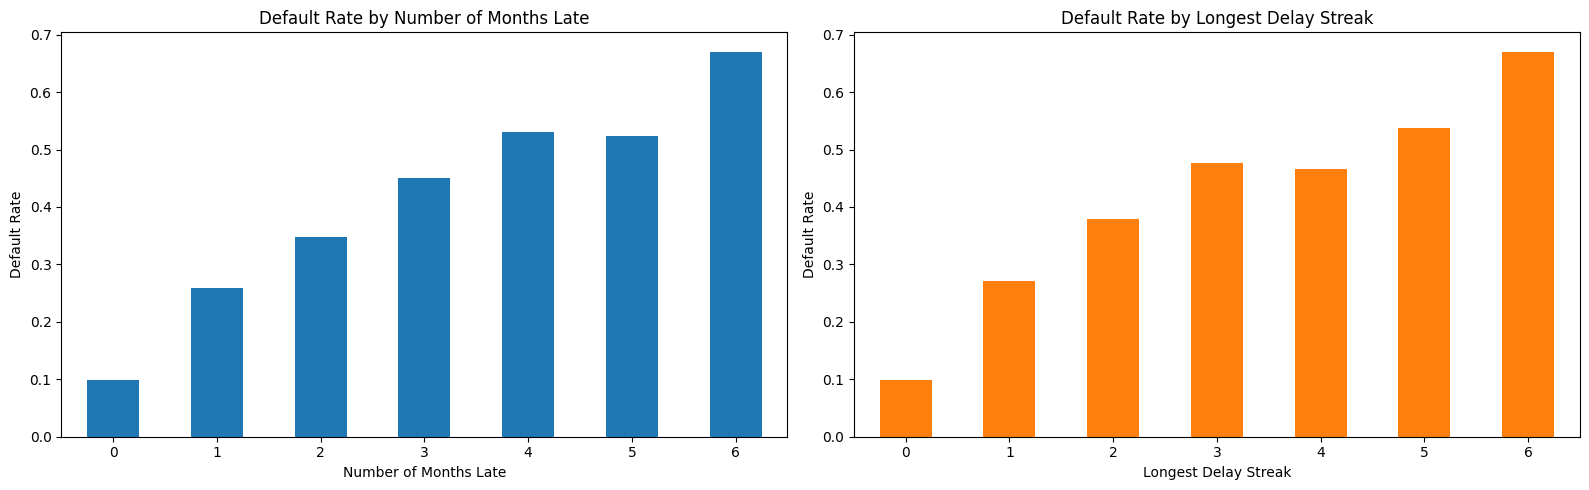

In [2113]:
num_months_late_rates = train_df.groupby('num_months_late')['next_month_default'].mean()
longest_streak_rates = train_df.groupby('longest_delay_streak')['next_month_default'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

num_months_late_rates.plot(kind='bar', color="#1f77b4", ax=axes[0])
axes[0].set_title('Default Rate by Number of Months Late')
axes[0].set_xlabel('Number of Months Late')
axes[0].set_ylabel('Default Rate')
axes[0].set_xticks(range(len(num_months_late_rates)))
axes[0].set_xticklabels(num_months_late_rates.index, rotation=0)

longest_streak_rates.plot(kind='bar', color="#ff7f0e", ax=axes[1])
axes[1].set_title('Default Rate by Longest Delay Streak')
axes[1].set_xlabel('Longest Delay Streak')
axes[1].set_ylabel('Default Rate')
axes[1].set_xticks(range(len(longest_streak_rates)))
axes[1].set_xticklabels(longest_streak_rates.index, rotation=0)

plt.tight_layout()
plt.show()

### Payment amounts

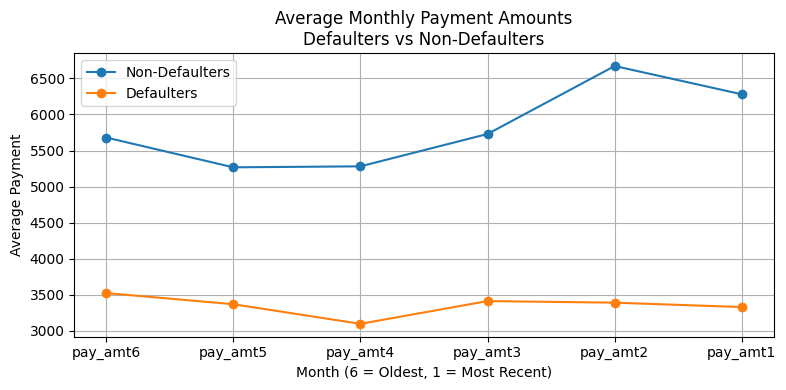

In [2114]:
# Payment columns (chronologically reversed)
pay_cols_amt = ['pay_amt6', 'pay_amt5', 'pay_amt4', 'pay_amt3', 'pay_amt2', 'pay_amt1']

# Group by default status and calculate average
pay_means = train_df.groupby('next_month_default')[pay_cols_amt].mean().T
pay_means.columns = ['Non-Defaulters', 'Defaulters'] if 0 in pay_means.columns else ['Defaulters', 'Non-Defaulters']

# Plot
pay_means.plot(figsize=(8, 4), marker='o')
plt.title("Average Monthly Payment Amounts\nDefaulters vs Non-Defaulters")
plt.xlabel("Month (6 = Oldest, 1 = Most Recent)")
plt.ylabel("Average Payment")
plt.grid(True)
plt.tight_layout()
plt.show()


In [2115]:
# Total payments over 6 months
train_df['total_payment'] = train_df[pay_cols_amt].sum(axis=1)

# Payment volatility (standard deviation)
train_df['payment_volatility'] = train_df[pay_cols_amt].std(axis=1)

# Payment trend (slope)
import numpy as np
months = np.arange(1, 7)
def compute_payment_slope(row):
    y = row[pay_cols_amt].values
    slope, _ = np.polyfit(months, y, deg=1)
    return slope

train_df['payment_slope'] = train_df[pay_cols_amt].apply(compute_payment_slope, axis=1)


In [2116]:
# Bin by payment slope

train_df['payment_slope_group'] = pd.cut(train_df['payment_slope'],
    bins=[-np.inf, -1000, 0, 1000, np.inf],
    labels=["Falling", "Stable", "Slightly Rising", "Rapidly Rising"]
)

print(train_df.groupby('payment_slope_group' , observed=True)['next_month_default'].mean().round(3))


payment_slope_group
Falling            0.124
Stable             0.236
Slightly Rising    0.204
Rapidly Rising     0.104
Name: next_month_default, dtype: float64


### Pay to Bill Ratio

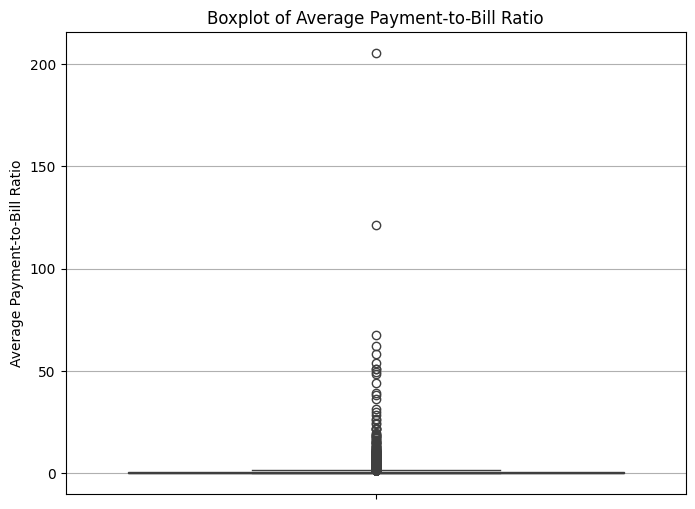

Number of outliers in PAY_TO_BILL_ratio: 756


In [2117]:
# boxplot for PAY_TO_BILL_ratio

plt.figure(figsize=(8, 6))
sns.boxplot(y='PAY_TO_BILL_ratio', data=train_df)
plt.title('Boxplot of Average Payment-to-Bill Ratio')
plt.ylabel('Average Payment-to-Bill Ratio')
plt.grid(axis='y')
plt.show()
# Number of outliers in PAY_TO_BILL_ratio
Q1 = train_df['PAY_TO_BILL_ratio'].quantile(0.25)
Q3 = train_df['PAY_TO_BILL_ratio'].quantile(0.75)
IQR = Q3 - Q1
outliers = train_df[(train_df['PAY_TO_BILL_ratio'] < (Q1 - 1.5 * IQR)) | (train_df['PAY_TO_BILL_ratio'] > (Q3 + 1.5 * IQR))]
print(f'Number of outliers in PAY_TO_BILL_ratio: {len(outliers)}')

In [2118]:
train_df['PAY_TO_BILL_ratio'].describe()

count    25247.000000
mean         0.434961
std          2.096024
min          0.000000
25%          0.040000
50%          0.090000
75%          0.590000
max        205.380000
Name: PAY_TO_BILL_ratio, dtype: float64

In [2119]:
# replace ratio larger than 50 with 50

train_df.loc[train_df['PAY_TO_BILL_ratio'] > 10, 'PAY_TO_BILL_ratio'] = 10

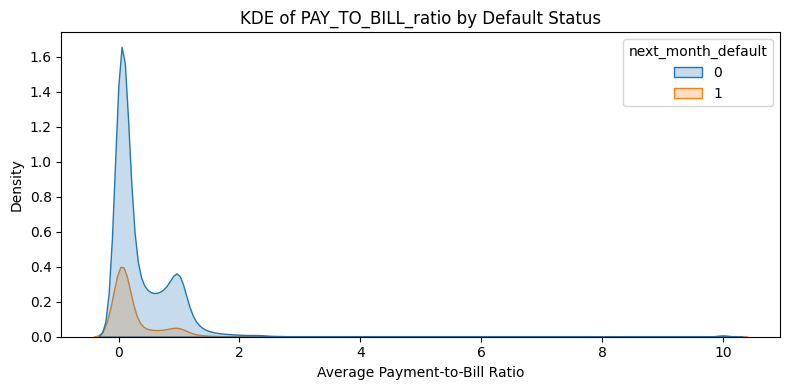

In [2120]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=train_df, x='PAY_TO_BILL_ratio', hue='next_month_default', fill=True)
plt.title("KDE of PAY_TO_BILL_ratio by Default Status")
plt.xlabel("Average Payment-to-Bill Ratio")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [2121]:
train_df['paybill_bin'] = pd.cut(train_df['PAY_TO_BILL_ratio'],
                                 bins=[-float('inf'), 0.2, 0.5, 0.8, 1.0, 1.5, float('inf')],
                                 labels=['<0.2', '0.2–0.5', '0.5–0.8', '0.8–1.0', '1.0–1.5', '>1.5'])

print(train_df.groupby('paybill_bin' , observed=True)['next_month_default'].mean().round(3))


paybill_bin
<0.2       0.228
0.2–0.5    0.127
0.5–0.8    0.128
0.8–1.0    0.137
1.0–1.5    0.122
>1.5       0.146
Name: next_month_default, dtype: float64


### New Features

In [2122]:
train_df['Util_0'] = (train_df['Bill_amt1'] + 1) / (train_df['LIMIT_BAL'] + 1)

bills = [f'Bill_amt{i}' for i in range(1,7)]
train_df['UTIL_max'] = train_df[bills].max(axis=1) / train_df['LIMIT_BAL']
train_df['UTIL_avg'] = train_df[bills].mean(axis=1) / train_df['LIMIT_BAL']

pay = [ 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']
train_df['streak'] = (train_df[pay] > 0).astype(int).groupby((train_df[pay] <= 0).any(axis=1).cumsum(), axis=0).cumsum().max(axis=1)

train_df['overdue_cnt'] = (train_df[pay] > 0).sum(axis=1)

train_df['on_time_ratio'] = (train_df[pay] <= 0).mean(axis=1)

train_df['bill_growth_1'] = (train_df['Bill_amt1'] - train_df['Bill_amt2'] + 1) / (train_df['Bill_amt2'] + 1)

pay_amts = [f'pay_amt{i}' for i in range(1, 7)]
bill_amts = [f'Bill_amt{i}' for i in range(1, 7)]

train_df['bill_std'] = train_df[bill_amts].std(axis=1, ddof=0)
train_df['pay_std'] = train_df[pay_amts].std(axis=1, ddof=0)

pay_cols = [f'pay_amt{i}' for i in range(1, 7)]
months = np.arange(1, 7)

def compute_payment_slope(row):
    y = row[pay_cols].astype(float).values
    if np.all(y == 0): 
        return 0.0
    m, _ = np.polyfit(months, y, 1)  
    return m

train_df['payment_slope'] = train_df.apply(compute_payment_slope, axis=1)

weights = np.array([0.2, 0.3, 0.5, 0.7, 0.9, 1.0])
train_df['pay_ewm_sum'] = train_df[pay_cols].values.dot(weights)


C:\Users\vagha\AppData\Local\Temp\ipykernel_24596\1642969575.py:8: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  train_df['streak'] = (train_df[pay] > 0).astype(int).groupby((train_df[pay] <= 0).any(axis=1).cumsum(), axis=0).cumsum().max(axis=1)


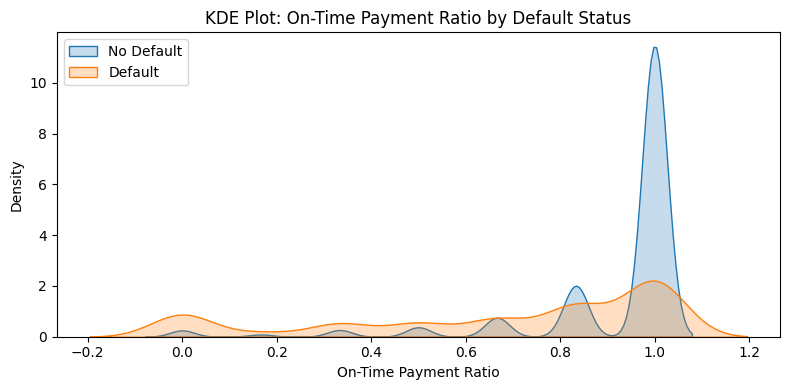

In [2123]:
# plot on time ratio with default status

plt.figure(figsize=(8, 4))
sns.kdeplot(
    data=train_df[train_df['next_month_default'] == 0],
    x='on_time_ratio',
    label='No Default',
    fill=True,
    color="#1f77b4"
)

sns.kdeplot(
    data=train_df[train_df['next_month_default'] == 1],
    x='on_time_ratio',
    label='Default',
    fill=True,
    color="#ff7f0e"
)

plt.title("KDE Plot: On-Time Payment Ratio by Default Status")
plt.xlabel("On-Time Payment Ratio")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# Feature Selection 

### Overall Correlation Matrix

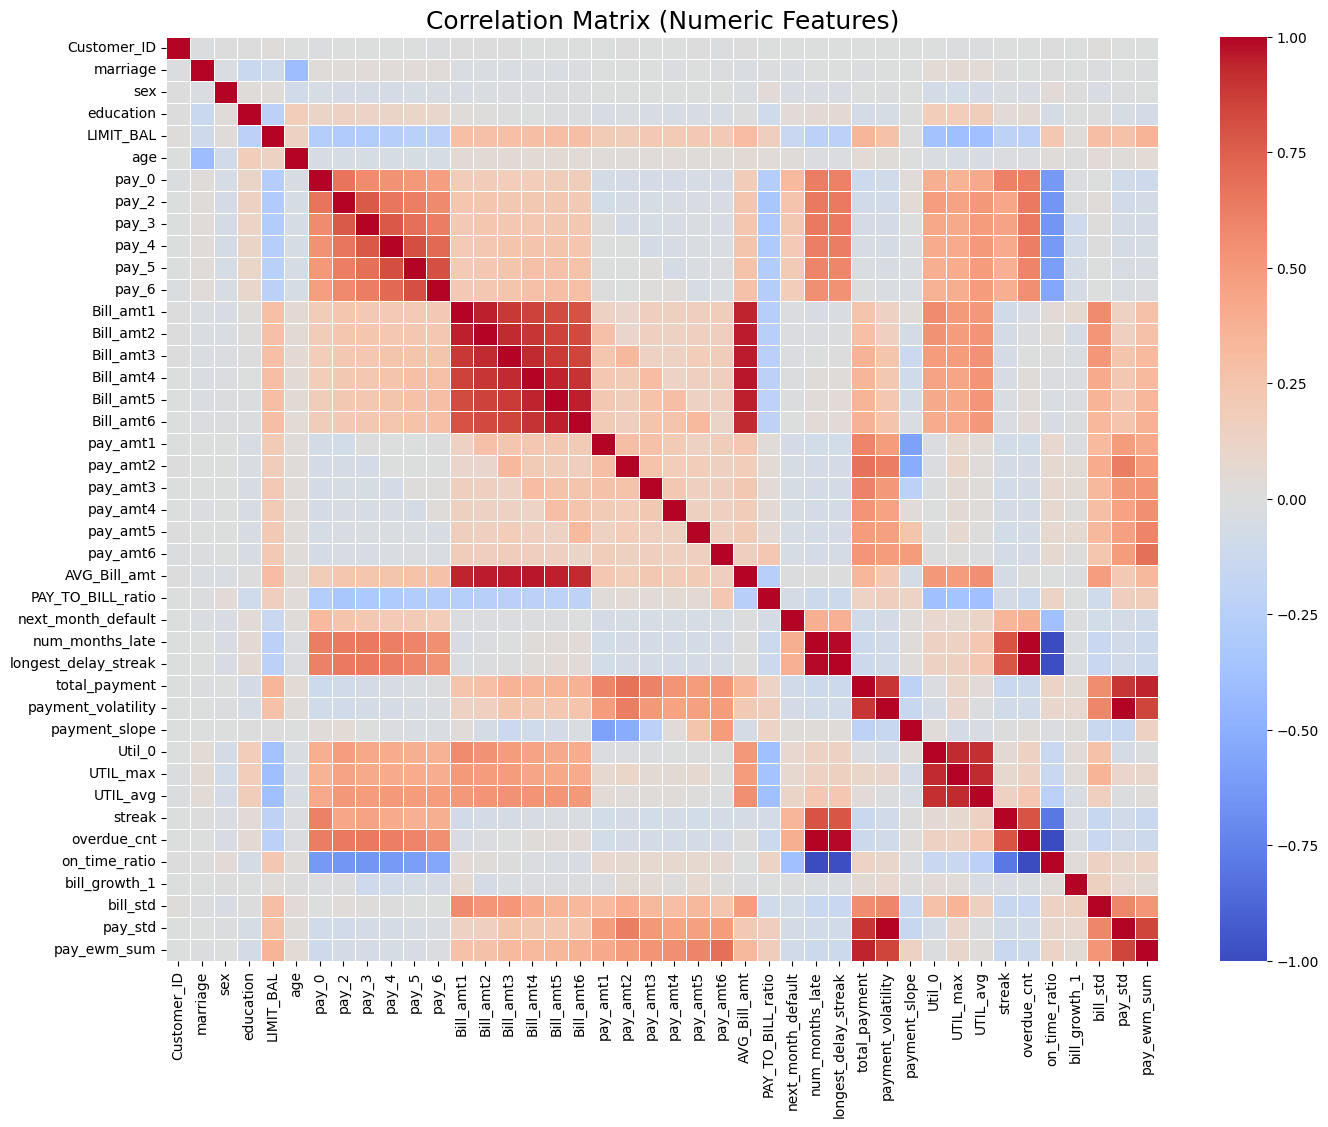

In [2124]:
# plot overall correlation matrix

numeric_df = train_df.select_dtypes(include='number')

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix (Numeric Features)', fontsize=18)
plt.show()

In [2125]:
# Final feature set

features = [
             'marriage',
             'LIMIT_BAL',
             'AVG_Bill_amt',
             'PAY_TO_BILL_ratio',
             'longest_delay_streak',
             'num_months_late',
             'Util_0',
             'UTIL_avg',
             'UTIL_max',
             'overdue_cnt',
             'on_time_ratio',
             'bill_growth_1',
             'bill_std',
             'pay_std',
             'pay_ewm_sum'
             ]

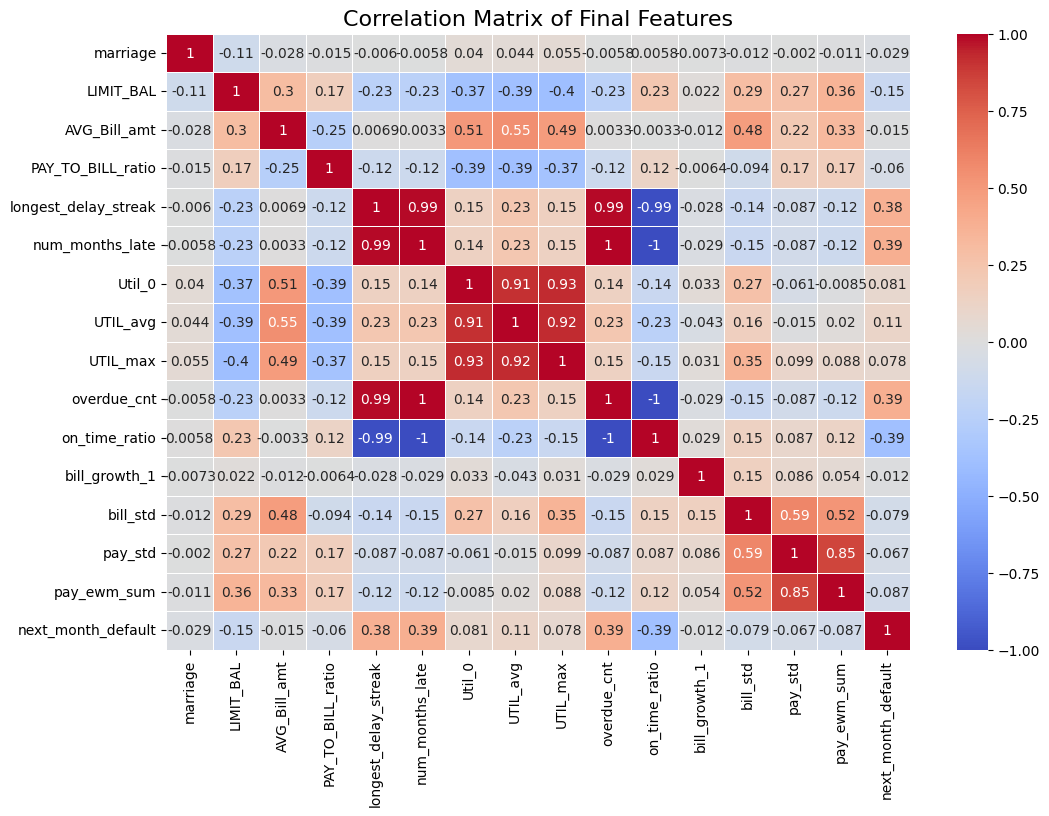

In [2126]:
# Select the features plus the target column correctly using a list
corr_matrix = train_df[features + ['next_month_default']].corr()

# Plot the heatmap for the final feature set
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix of Final Features', fontsize=16)
plt.show()


# Model Training

### Logistic Regression

In [2127]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, 
    precision_recall_curve
)

In [2128]:
X = train_df[features]
y = train_df['next_month_default']

# drop if not numerical columns

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [2129]:
model = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',  # supports L1 or L2 penalty
    penalty='l2',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')

In [2130]:
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]


In [2131]:
print("Accuracy :", accuracy_score(y_val, y_pred))
print("Recall   :", recall_score(y_val, y_pred))
print("F1 Score :", f1_score(y_val, y_pred))
print("AUC ROC  :", roc_auc_score(y_val, y_prob))

precision, recall, thresholds = precision_recall_curve(y_val, y_prob)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-8)
best_idx = np.argmax(f2_scores)

print("Best F2 Score:", f2_scores[best_idx])
print("Optimal Threshold:", thresholds[best_idx])

Accuracy : 0.7679207920792079
Recall   : 0.5769230769230769
F1 Score : 0.4864154250657318
AUC ROC  : 0.739765186682995
Best F2 Score: 0.572818154134726
Optimal Threshold: 0.3816520175176372


In [2132]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

model_sm = LogisticRegression(class_weight=None, max_iter=1000, solver='liblinear')
model_sm.fit(X_train_sm, y_train_sm)

y_pred = model_sm.predict(X_val)
y_prob = model_sm.predict_proba(X_val)[:, 1]

# Evaluate
print("Accuracy :", accuracy_score(y_val, y_pred))
print("Recall   :", recall_score(y_val, y_pred))
print("F1 Score :", f1_score(y_val, y_pred))
print("AUC ROC  :", roc_auc_score(y_val, y_prob))

# F2 Score
precision, recall, thresholds = precision_recall_curve(y_val, y_prob)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-8)
best_idx = f2_scores.argmax()

print("Best F2 Score:", f2_scores[best_idx])
print("Optimal Threshold:", thresholds[best_idx])

Accuracy : 0.758019801980198
Recall   : 0.5467775467775468
F1 Score : 0.46262093227792433
AUC ROC  : 0.7255343462535243
Best F2 Score: 0.5651664901112157
Optimal Threshold: 0.3937777139350704


In [2133]:
from sklearn.linear_model import LogisticRegressionCV

modelx = LogisticRegressionCV(
    Cs=10,
    cv=5,
    scoring='f1',
    class_weight='balanced',
    max_iter=1000,
    penalty='l2',
    solver='liblinear'
)
modelx.fit(X_train, y_train)


LogisticRegressionCV(class_weight='balanced', cv=5, max_iter=1000, scoring='f1',
                     solver='liblinear')

In [2134]:
y_pred = modelx.predict(X_val)
y_prob = modelx.predict_proba(X_val)[:, 1]

# Evaluate
print("Accuracy :", accuracy_score(y_val, y_pred))
print("Recall   :", recall_score(y_val, y_pred))
print("F1 Score :", f1_score(y_val, y_pred))
print("AUC ROC  :", roc_auc_score(y_val, y_prob))

# F2 Score
precision, recall, thresholds = precision_recall_curve(y_val, y_prob)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-8)
best_idx = f2_scores.argmax()

print("Best F2 Score:", f2_scores[best_idx])
print("Optimal Threshold:", thresholds[best_idx])

Accuracy : 0.7693069306930693
Recall   : 0.5644490644490644
F1 Score : 0.4824522434473567
AUC ROC  : 0.7480283045351538
Best F2 Score: 0.5800388823539314
Optimal Threshold: 0.40180872643108695


### Random Forest

In [2135]:
from sklearn.ensemble import RandomForestClassifier

In [2136]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,  # control overfitting (you can tune this later)
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_val)
y_prob = rf_model.predict_proba(X_val)[:, 1]

# Basic Metrics
print("Accuracy :", accuracy_score(y_val, y_pred))
print("Recall   :", recall_score(y_val, y_pred))
print("F1 Score :", f1_score(y_val, y_pred))
print("AUC ROC  :", roc_auc_score(y_val, y_prob))

# F2 Score
precision, recall, thresholds = precision_recall_curve(y_val, y_prob)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-8)
best_idx = f2_scores.argmax()

print("Best F2 Score:", f2_scores[best_idx])
print("Optimal Threshold:", thresholds[best_idx])

Accuracy : 0.7792079207920792
Recall   : 0.581081081081081
F1 Score : 0.5006717420510524
AUC ROC  : 0.7739484460374871
Best F2 Score: 0.6067837026499804
Optimal Threshold: 0.3595934547554801


### LightGBM

In [2137]:
import lightgbm as lgb

In [2138]:
lgb_model = lgb.LGBMClassifier(
    objective='binary',
    class_weight='balanced',
    random_state=42,
    n_estimators=100,
    learning_rate=0.05,
    max_depth=8
)

# Train the model
lgb_model.fit(X_train, y_train)

# Predict
y_pred = lgb_model.predict(X_val)
y_prob = lgb_model.predict_proba(X_val)[:, 1]

# Metrics
print("Accuracy :", accuracy_score(y_val, y_pred))
print("Recall   :", recall_score(y_val, y_pred))
print("F1 Score :", f1_score(y_val, y_pred))
print("AUC ROC  :", roc_auc_score(y_val, y_prob))

# F2 Score and Threshold
precision, recall, thresholds = precision_recall_curve(y_val, y_prob)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-8)
best_idx = np.argmax(f2_scores)

print("Best F2 Score:", f2_scores[best_idx])
print("Optimal Threshold:", thresholds[best_idx])

[LightGBM] [Info] Number of positive: 3845, number of negative: 16352
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000935 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2383
[LightGBM] [Info] Number of data points in the train set: 20197, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Accuracy : 0.7514851485148515
Recall   : 0.6559251559251559
F1 Score : 0.5013905442987684
AUC ROC  : 0.7762296015720674
Best F2 Score: 0.6136327662774487
Optimal Threshold: 0.3659195007571559


### XGBoost

In [2139]:
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, precision_recall_curve
)
import numpy as np

# Estimate scale_pos_weight for imbalance
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

# Build model
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    learning_rate=0.05,
    max_depth=6,
    n_estimators=100,
    random_state=42
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_val)
y_prob = xgb_model.predict_proba(X_val)[:, 1]

# Evaluate
print("Accuracy :", accuracy_score(y_val, y_pred))
print("Recall   :", recall_score(y_val, y_pred))
print("F1 Score :", f1_score(y_val, y_pred))
print("AUC ROC  :", roc_auc_score(y_val, y_prob))

# F2 and optimal threshold
precision, recall, thresholds = precision_recall_curve(y_val, y_prob)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-8)
best_idx = np.argmax(f2_scores)
print("Best F2 Score:", f2_scores[best_idx])
print("Optimal Threshold:", thresholds[best_idx])

Accuracy : 0.7554455445544555
Recall   : 0.6486486486486487
F1 Score : 0.5026178010471204
AUC ROC  : 0.7749855314067642
Best F2 Score: 0.6149059089234887
Optimal Threshold: 0.31428874


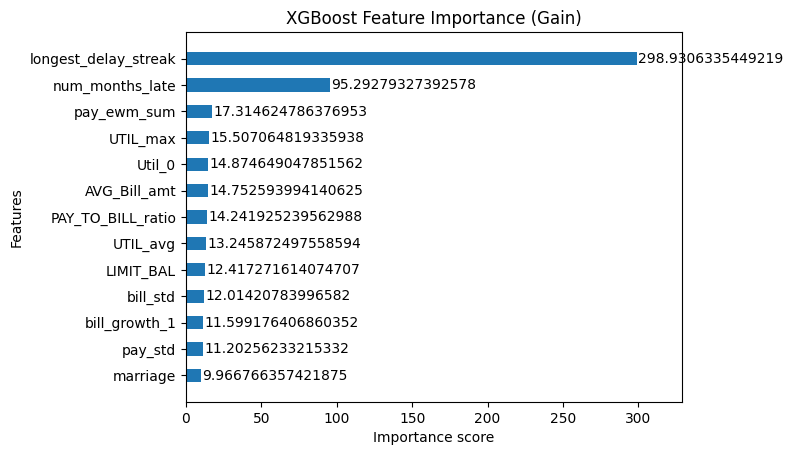

In [2140]:
xgb.plot_importance(
    xgb_model,
    importance_type='gain',
    max_num_features=50,
    height=0.5,
    grid=False,
    title='XGBoost Feature Importance (Gain)'
)
plt.show()

# Final Predictions on Validation dataset (Provided)

### Loading Validation Data

In [2141]:
test_df = pd.read_csv('validate_dataset_final.csv')

In [2142]:
test_df.shape

(5016, 26)

### Calculating new Features required for Prediction

In [2143]:
# 1. longest delay streak
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']

test_df['num_months_late'] = test_df[pay_cols].apply(lambda row: sum(row >= 1), axis=1)

In [2144]:
# 2. Longest delay streak

def longest_streak(row):
    streak = max_streak = 0
    for val in row:
        if val >= 1:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

test_df['longest_delay_streak'] = test_df[pay_cols].apply(longest_streak, axis=1)

In [2145]:
# 3. Utilization ratios

bills = [f'Bill_amt{i}' for i in range(1,7)]

test_df['Util_0'] = (test_df['Bill_amt1'] + 1) / (test_df['LIMIT_BAL'] + 1)
test_df['UTIL_max'] = test_df[bills].max(axis=1) / test_df['LIMIT_BAL']
test_df['UTIL_avg'] = test_df[bills].mean(axis=1) / test_df['LIMIT_BAL']

In [2146]:
# 4. Overdue count

test_df['overdue_cnt'] = (test_df[pay] > 0).sum(axis=1)

In [2147]:
# 5. On-time payment ratio

test_df['on_time_ratio'] = (test_df[pay] <= 0).mean(axis=1)

In [2148]:
# 6. Bill growth ratio

test_df['bill_growth_1'] = (test_df['Bill_amt1'] - test_df['Bill_amt2'] + 1) / (test_df['Bill_amt2'] + 1)

In [2149]:
# 7. Standard deviation of bill and payment amounts

pay_amts = [f'pay_amt{i}' for i in range(1, 7)]
bill_amts = [f'Bill_amt{i}' for i in range(1, 7)]

test_df['bill_std'] = test_df[bill_amts].std(axis=1, ddof=0)
test_df['pay_std'] = test_df[pay_amts].std(axis=1, ddof=0)

In [2150]:
# 8. Weighted sum of payments

pay_cols = [f'pay_amt{i}' for i in range(1, 7)]

weights = np.array([0.2, 0.3, 0.5, 0.7, 0.9, 1.0])
test_df['pay_ewm_sum'] = test_df[pay_cols].values.dot(weights)

### Predictions from XGBoost Model

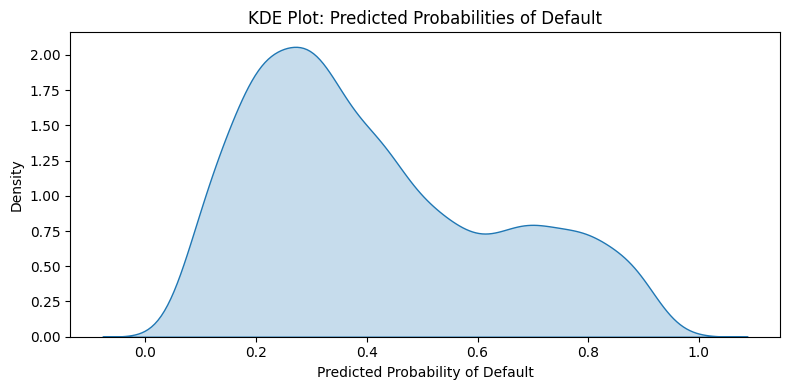

In [2151]:
X_val = test_df[features]

probs = xgb_model.predict_proba(X_val)[:, 1]

# kde plot the distribution of probabilities

plt.figure(figsize=(8, 4))
sns.kdeplot(probs, fill=True, color="#1f77b4")
plt.title("KDE Plot: Predicted Probabilities of Default")
plt.xlabel("Predicted Probability of Default")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [2152]:

threshold = 0.31428874

predictions = (probs >= threshold).astype(int)

In [2153]:
# count the number of defaults predicted

num_defaults = np.sum(predictions)
print(f"Number of defaults predicted: {num_defaults}")
print(f"Number of non-defaults predicted: {len(predictions) - num_defaults}")

Number of defaults predicted: 2910
Number of non-defaults predicted: 2106


### Prepare Dataset and Create CSV File

In [2154]:
submission = pd.DataFrame({
    "Customer_ID": test_df['Customer_ID'],
    "next_month_default": predictions
})

submission.to_csv("submission_23114104.csv", index=False)
print("Saved: submission_23114104.csv")

Saved: submission_23114104.csv


# Thank You !